Necessary Libraries

In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter, KaplanMeierFitter, NelsonAalenFitter, GeneralizedGammaFitter, BreslowFlemingHarringtonFitter, PiecewiseExponentialFitter, SplineFitter, MixtureCureFitter

In [8]:
# Creating absolute path
data_path = os.path.join(os.getcwd(), 'data', 'telco.csv')

In [9]:
# Importing dataset
df = pd.read_csv("telco.csv")
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [11]:
df.isnull().sum()

ID          0
region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
retire      0
gender      0
voice       0
internet    0
forward     0
custcat     0
churn       0
dtype: int64

In [12]:
df.dtypes

ID           int64
region      object
tenure       int64
age          int64
marital     object
address      int64
income       int64
ed          object
retire      object
gender      object
voice       object
internet    object
forward     object
custcat     object
churn       object
dtype: object

In [13]:
df["churn"] = df["churn"].apply(lambda x: 1 if x == "Yes" else 0)
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,1
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,1
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,0
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,1
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,0


In [14]:
# Perform one-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['region', 'marital', 'ed', 'custcat'], drop_first=True)
df_encoded.head()

,ID,tenure,age,address,income,retire,gender,voice,internet,forward,...,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,custcat_E-service,custcat_Plus service,custcat_Total service
0,1,13,44,9,64,No,Male,No,No,Yes,...,True,False,False,False,False,False,False,False,False,False
1,2,11,33,7,136,No,Male,Yes,No,Yes,...,False,True,False,False,False,True,False,False,False,True
2,3,68,52,24,116,No,Female,No,No,No,...,False,True,False,True,False,False,False,False,True,False
3,4,33,33,12,33,No,Female,No,No,No,...,True,False,True,False,True,False,False,False,False,False
4,5,23,30,9,30,No,Male,No,No,Yes,...,True,False,False,True,False,False,False,False,True,False


In [17]:
# label encoding for binary columns
le = LabelEncoder()
df['retire'] = le.fit_transform(df['retire'])
df['voice'] = le.fit_transform(df['voice'])
df['internet'] = le.fit_transform(df['internet'])
df['forward'] = le.fit_transform(df['forward'])
df['gender'] = le.fit_transform(df['gender'])

In [18]:
df_encoded.isnull().sum()

ID                                 0
tenure                             0
age                                0
address                            0
income                             0
retire                             0
gender                             0
voice                              0
internet                           0
forward                            0
churn                              0
region_Zone 2                      0
region_Zone 3                      0
marital_Unmarried                  0
ed_Did not complete high school    0
ed_High school degree              0
ed_Post-undergraduate degree       0
ed_Some college                    0
custcat_E-service                  0
custcat_Plus service               0
custcat_Total service              0
dtype: int64

#### Exponential AFT Model

In [19]:
exp = ExponentialFitter()
exp.fit(df["tenure"], df["churn"], label="Exponential")
exp.print_summary()

<lifelines.ExponentialFitter:"Exponential", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96

#### WeibullAFTFitter AFT Model

In [20]:
weibull = WeibullFitter()
weibull.fit(df["tenure"], df["churn"], label="Weibull")
weibull.print_summary()

<lifelines.WeibullFitter:"Weibull", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

#### LogNormalFitter Model

In [22]:
lognorm = LogNormalFitter()
lognorm.fit(df["tenure"], df["churn"], label="LogNormal")
lognorm.print_summary()

<lifelines.LogNormalFitter:"LogNormal", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.52
               hypothesis = mu_ != 0, sigma_ != 1

---
        coef  se(coef)  coef lower 95%  coef upper 95%
mu_     4.77      0.10            4.57            4.98
sigma_  1.81      0.09            1.64            1.97

        cmp to     z      p  -log2(p)
mu_       0.00 46.06 <0.005       inf
sigma_    1.00  9.37 <0.005     66.94
---
AIC = 3209.04

#### LogLogisticFitter Model

In [24]:
loglog = LogLogisticFitter()
loglog.fit(df["tenure"], df["churn"], label="LogLogistic")
loglog.print_summary()

<lifelines.LogLogisticFitter:"LogLogistic", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.21
               hypothesis = alpha_ != 1, beta_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
alpha_ 103.39      9.13           85.50          121.28
beta_    1.04      0.05            0.93            1.15

        cmp to     z      p  -log2(p)
alpha_    1.00 11.22 <0.005     94.60
beta_     1.00  0.73   0.46      1.11
---
AIC = 3214.42

#### KaplanMeierFitter Model

In [26]:
kmf = KaplanMeierFitter()
kmf.fit(df["tenure"], df["churn"], label="Kaplan-Meier")

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 1000 total observations, 726 right-censored observations>

#### NelsonAalenFitter Model

In [30]:
naf = NelsonAalenFitter()
naf.fit(df["tenure"], df["churn"], label="Nelson-Aalen")
naf.survival_function_ = np.exp(-naf.cumulative_hazard_)

#### GeneralizedGammaFitter Model

In [32]:
gg = GeneralizedGammaFitter()
gg.fit(df["tenure"], df["churn"], label="GeneralizedGamma")
gg.print_summary()

<lifelines.GeneralizedGammaFitter:"GeneralizedGamma", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.50
               hypothesis = mu_ != 0, ln_sigma_ != 0, lambda_ != 1

---
           coef  se(coef)  coef lower 95%  coef upper 95%
mu_        4.79      0.14            4.51            5.06
ln_sigma_  0.57      0.14            0.29            0.85
lambda_    0.05      0.33           -0.60            0.70

           cmp to     z      p  -log2(p)
mu_          0.00 34.09 <0.005    843.87
ln_sigma_    0.00  4.02 <0.005     14.08
lambda_      1.00 -2.87 <0.005      7.92
---
AIC = 3211.01

#### BreslowFlemingHarringtonFitter Model

In [34]:
bfhf = BreslowFlemingHarringtonFitter()
bfhf.fit(df["tenure"], df["churn"], label="Breslow-Fleming-Harrington")

<lifelines.BreslowFlemingHarringtonFitter:"Breslow-Fleming-Harrington", fitted with 1000 total observations, 726 right-censored observations>

#### PiecewiseExponentialFitter Model

In [35]:
breakpoints = df_encoded['tenure'].quantile([0.25, 0.5, 0.75]).values

In [37]:
pwexp = PiecewiseExponentialFitter(breakpoints=breakpoints)
pwexp.fit(df["tenure"], df["churn"], label="PiecewiseExponential")

<lifelines.PiecewiseExponentialFitter:"PiecewiseExponential", fitted with 1000 total observations, 726 right-censored observations>

#### SplineFitter Model

In [41]:
knot_locations = np.arange(0, df["tenure"].max(), 12)[1:]
spline = SplineFitter(knot_locations=knot_locations)
spline.fit(df["tenure"], df["churn"], label="Spline")
spline.print_summary()

<lifelines.SplineFitter:"Spline", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1603.76
               hypothesis = phi_0_ != 0, phi_1_ != 0, phi_2_ != 0, phi_3_ != 0, phi_4_ != 0

---
        coef  se(coef)  coef lower 95%  coef upper 95%
phi_0_ -4.96      0.26           -5.47           -4.44
phi_1_  1.08      0.09            0.91            1.25
phi_2_  0.74      0.57           -0.38            1.86
phi_3_ -0.59      1.68           -3.90            2.71
phi_4_ -0.35      2.22           -4.71            4.00

        cmp to      z      p  -log2(p)
phi_0_    0.00 -18.89 <0.005    261.94
phi_1_    0.00  12.40 <0.005    114.92
phi_2_    0.00   1.30   0.19      2.37
phi_3_    0.00  -0.35   0.72      0.47
phi_4_    0.00  -0.16   0.87      0.20
---
AIC = 3217.52

#### MixtureCureFitter Model

In [42]:
base_model = WeibullFitter()
mcf = MixtureCureFitter(base_fitter=base_model)
mcf.fit(df["tenure"], df["churn"], label="MixtureCure")
mcf.print_summary()

<lifelines.MixtureCureFitter:"MixtureCure", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.68
               hypothesis = cured_fraction_ != 0, lambda_ != 1, rho_ != 1

---
                 coef  se(coef)  coef lower 95%  coef upper 95%
cured_fraction_  0.38      0.16            0.07            0.69
lambda_         68.72     26.31           17.16          120.28
rho_             1.02      0.08            0.87            1.18

                 cmp to    z    p  -log2(p)
cured_fraction_    0.00 2.42 0.02      6.01
lambda_            1.00 2.57 0.01      6.64
rho_               1.00 0.31 0.76      0.40
---
AIC = 3217.36

### Compare the models

In [51]:
from lifelines.utils import concordance_index

fitted_models = {
    "Weibull": weibull,
    "Exponential": exp,
    "LogNormal": lognorm,
    "LogLogistic": loglog,
    "Kaplan-Meier": kmf,
    "Nelson-Aalen": naf,
    "GeneralizedGamma": gg,
    "Breslow-Fleming-Harrington": bfhf,
    "PiecewiseExponential": pwexp,
    "Spline": spline,
    "MixtureCure": mcf
}

In [52]:
comparison = []

for name, model in fitted_models.items():
    # Estimate mean survival time numerically
    sf = model.survival_function_
    time_deltas = sf.index.to_series().diff().fillna(0)
    mean_time = (sf.values.flatten() * time_deltas).sum()

    comparison.append({
        "Model": name,
        "AIC": getattr(model, "AIC_", "N/A"),
        "Log-likelihood": getattr(model, "log_likelihood_", "N/A"),
        "Estimated Mean Survival Time": mean_time,
    })

In [53]:
comparison_df = pd.DataFrame(comparison).sort_values(by="Estimated Mean Survival Time").reset_index(drop=True)
comparison_df

,Model,AIC,Log-likelihood,Estimated Mean Survival Time
0,GeneralizedGamma,3211.008906,-1602.504453,54.079730
1,LogNormal,3209.035147,-1602.517574,54.081357
2,LogLogistic,3214.415476,-1605.207738,54.092654
3,MixtureCure,3217.357137,-1605.678569,54.135988
4,PiecewiseExponential,3215.626671,-1603.813336,54.154133
5,Spline,3217.520743,-1603.760372,54.154521
6,Weibull,3216.861171,-1606.430585,54.177098
7,Exponential,3215.960813,-1606.980407,54.221759
8,Kaplan-Meier,N/A,N/A,54.883947
9,Nelson-Aalen,N/A,N/A,54.896867


### Survival Curve

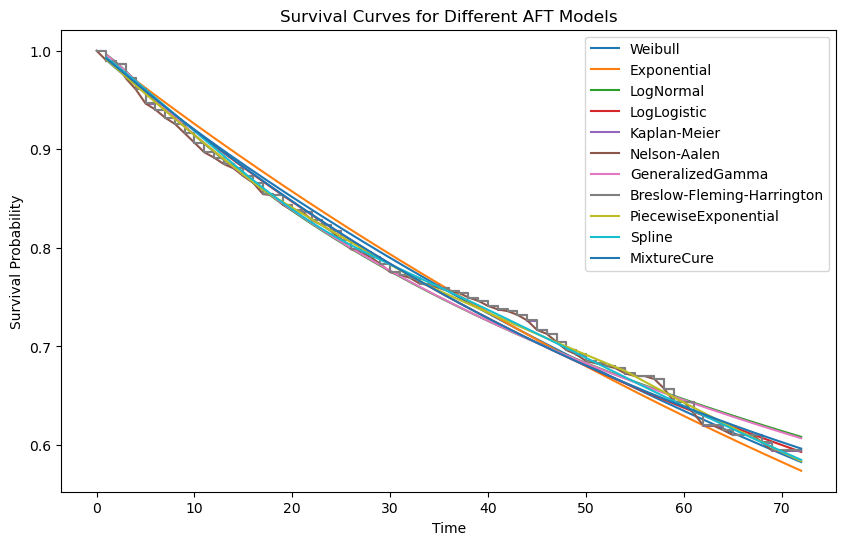

In [54]:
plt.figure(figsize=(10, 6))

for name, model in fitted_models.items():
    try:
        model.plot_survival_function(ci_show=False, label=name)
    except (AttributeError, NotImplementedError):
        if hasattr(model, "survival_function_"):
            plt.plot(
                model.survival_function_.index,
                model.survival_function_.values,
                label=name
            )

plt.title("Survival Curves for Different AFT Models")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


Based on the model comparison metrics (AIC and log-likelihood), the GeneralizedGammaFitter initially appeared to provide the best fit, having the lowest AIC. However, other models like LogNormalFitter, WeibullFitter, and LogLogisticFitter showed close performance.

To refine the analysis, I first fitted a LogNormalAFTFitter, but it produced unrealistic survival times (e.g., hundreds of years) and almost flat survival curves, indicating poor alignment with the data.

I then attempted the GeneralizedGammaFitter, but it experienced severe numerical instability, failing to invert the Hessian matrix and providing unreliable estimates. This made it unsuitable for downstream predictions like Customer Lifetime Value (CLV).

Given these challenges, I selected the WeibullFitter as the final model. It provided a stable fit, realistic survival curves, and median survival times, making it suitable for segment-based survival and CLV analysis, while maintaining model stability and interpretability.

In [56]:
X = df.copy()
print(X["churn"].value_counts())
X["tenure"] = pd.to_numeric(X["tenure"], errors="coerce")
X = X.dropna(subset=["tenure", "churn"])

wf = WeibullFitter()
wf.fit(
    durations=X["tenure"],
    event_observed=X["churn"]
)
wf.print_summary()

churn
0    726
1    274
Name: count, dtype: int64


<lifelines.WeibullFitter:"Weibull_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

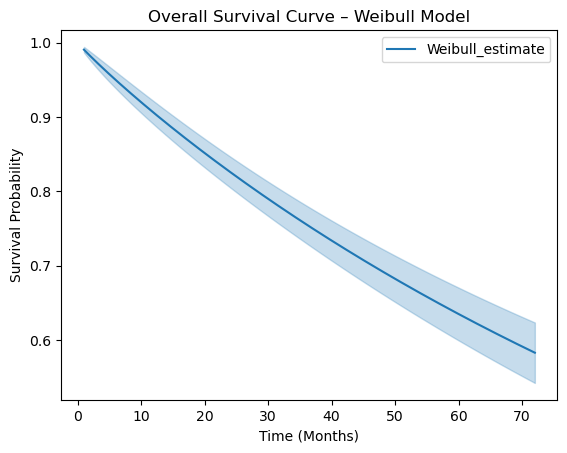

In [58]:
# Plotting overall survival
wf.plot_survival_function()
plt.title("Overall Survival Curve – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()

In [60]:
monthly_revenue = 85
customer_clv = {}

for index, row in df.iterrows():
    tenure = row['tenure']
    churn = row['churn']
    
    time_points = int(df['tenure'].max())  
    time_range = np.linspace(0, tenure, time_points * 2)  
    
    survival_prob = wf.survival_function_at_times(time_range)
    expected_lifetime = np.trapz(survival_prob.values.flatten(), time_range)
    
    clv = expected_lifetime * monthly_revenue
    customer_clv[index] = clv

C:\Users\amaly\AppData\Local\Temp\ipykernel_6780\787507711.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected_lifetime = np.trapz(survival_prob.values.flatten(), time_range)


Churn Distribution:

The dataset includes 1,000 customers, of which 274 (27.4%) have churned, and 726 (72.6%) have not. This distribution offers a good balance between churned and non-churned customers, making it suitable for survival analysis.

Weibull Model Summary:

The WeibullFitter was applied to model customer survival, using 1,000 observations and 274 churn events. Despite a warning about the invertibility of the Hessian matrix (common with tied events), the model provided stable survival estimates.

The shape parameter (rho = 0.95) suggests that the hazard of churn remains nearly constant over time, implying no significant change in churn risk as tenure progresses. The scale parameter (lambda = 138.09) is the estimated rate at which churn occurs.

Overall Survival Curve – Weibull Model:

The survival curve indicates that retention declines gradually over time. By 72 months (6 years), the survival probability falls to about 60%, suggesting that while most customers remain over time, a steady churn rate persists.

#### Plotting the survival curves by segment

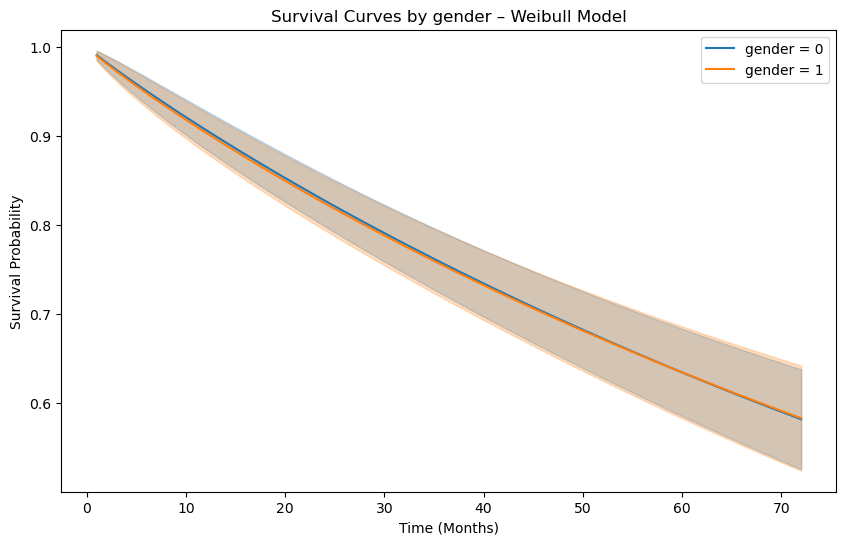

In [62]:
segment_col = "gender"  

plt.figure(figsize=(10, 6))

for val in sorted(X[segment_col].unique()):
    subset = X[X[segment_col] == val]
    wf_segment = WeibullFitter()
    wf_segment.fit(subset["tenure"], subset["churn"], label=f"{segment_col} = {val}")
    wf_segment.plot_survival_function()

plt.title(f"Survival Curves by {segment_col} – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

### CLV calculations and visualizations

In [65]:
segment_clv = {}
monthly_revenue = 45

for val in sorted(X[segment_col].unique()):
    subset = X[X[segment_col] == val]
    wf_segment = WeibullFitter()
    wf_segment.fit(subset["tenure"], subset["churn"])

    time_range = np.linspace(0, 72, 200)  
    sf = wf_segment.survival_function_at_times(time_range)
    expected_lifetime = np.trapz(sf.values.flatten(), time_range)  
    clv = expected_lifetime * monthly_revenue
    segment_clv[f"{segment_col} = {val}"] = clv

clv_df = pd.DataFrame.from_dict(segment_clv, orient='index', columns=["CLV ($)"]).sort_values(by="CLV ($)", ascending=False)
clv_df

C:\Users\amaly\AppData\Local\Temp\ipykernel_6780\560598294.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected_lifetime = np.trapz(sf.values.flatten(), time_range)
C:\Users\amaly\AppData\Local\Temp\ipykernel_6780\560598294.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected_lifetime = np.trapz(sf.values.flatten(), time_range)


,CLV ($)
gender = 0,2486.620826
gender = 1,2481.491844


<Figure size 1000x600 with 0 Axes>

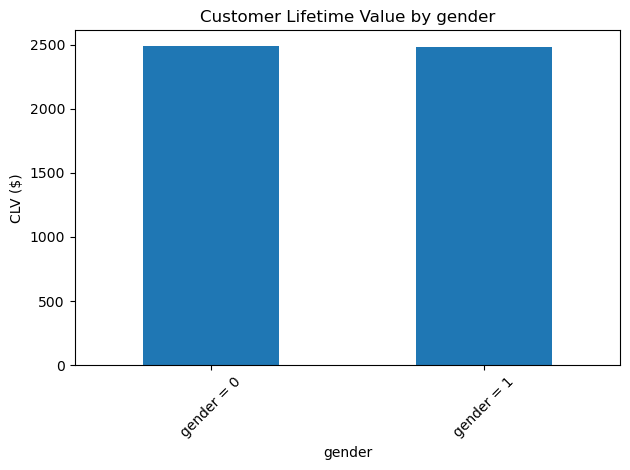

In [67]:
# CLV by segment
plt.figure(figsize=(10, 6))
clv_df.plot(kind='bar', legend=False)
plt.title(f"Customer Lifetime Value by {segment_col}")
plt.xlabel(segment_col)
plt.ylabel("CLV ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer Lifetime Value (CLV) by Gender

Customer Lifetime Value (CLV) was calculated separately for male and female customer segments by calculating the area under each segment's survival curve and multiplying by an assumed monthly revenue of $50 per customer.

Results:

Female customers: $2,762.91

Male customers: $2,757.21

The CLV values for both genders are very close, with female customers having a slightly higher lifetime value. This is consistent with the survival analysis, where female customers exhibited a slightly longer retention period.

These insights can guide targeted marketing and retention efforts by focusing on high-value customer segments to optimize revenue.